# Process Signal Reliability and Context Screening
Measures whether a hitter's process signals become usable faster per plate appearance than his
outcome line, and which of the 48 context features an XGBoost head actually uses. Every number
is read from committed artifacts and nothing is recomputed here, so the tested modules stay the
authority and this notebook is only the writeup.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import feature_screening_report
from src.data import labels

## Configuration
Artifact location and display settings. The artifacts are regenerated by the seeded commands
`python -m src.analysis.feature_screening_report` and `python -m src.analysis.feature_screening_screen`.

In [2]:
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

RESULTS_DIR = REPO_ROOT / "results/feature_screening"


def load(name):
    """Read one committed artifact by filename."""
    return pd.read_csv(RESULTS_DIR / name)

## Run parameters read from their owner modules
Every threshold and run parameter is imported rather than retyped. The spray check below became
a silent no-op once its threshold moved into labels.py, so a moved constant now breaks this cell
instead of going unnoticed.

In [3]:
pd.Series({
    "max train season": feature_screening_report.MAX_TRAIN_SEASON,
    "split half sample size grid": str(feature_screening_report.GRID),
    "bootstrap resamples": feature_screening_report.N_BOOT,
    "seed": feature_screening_report.SEED,
    "spray abs max, degrees": labels.SPRAY_ABS_MAX,
}, name="value").to_frame()

,value
max train season,2023
split half sample size grid,"[10, 25, 50, 100, 200, 400, 800]"
bootstrap resamples,300
seed,0
"spray abs max, degrees",90.0


## Stabilization points for process and outcome metrics
A stabilization point is the number of observations at which reliability reaches a threshold, so
smaller means the signal becomes usable sooner. The variance components columns are the headline
and the two split half columns are an independent cross check, taken randomly and chronologically.

In [4]:
panel = load("stabilization_panel.csv")
panel[["metric", "unit", "n_hitters", "vc_n50", "vc_n50_lo", "vc_n50_hi",
       "vc_n70", "splithalf_random_50", "splithalf_sequential_50"]].round(1)

,metric,unit,n_hitters,vc_n50,vc_n50_lo,vc_n50_hi,vc_n70,splithalf_random_50,splithalf_sequential_50
0,swing rate,pitches,1756,122.9,111.1,136.7,286.8,108.7,72.3
1,whiff rate,swings,1730,54.3,49.6,59.8,126.7,40.8,42.9
2,exit velocity,BBIP,1681,45.2,40.3,50.7,105.4,39.8,36.6
3,launch angle,BBIP,1681,46.4,42.5,51.4,108.2,38.2,38.9
4,spray angle,BBIP,1681,77.4,68.6,87.0,180.7,78.1,55.0
5,whiff vs LHP,swings,1627,48.9,44.1,54.3,114.0,37.7,40.3
6,whiff vs RHP,swings,1705,52.8,47.9,59.1,123.3,40.4,40.8
7,exit velocity vs LHP,BBIP,1593,36.5,32.1,42.1,85.1,37.1,43.2
8,exit velocity vs RHP,BBIP,1658,41.8,37.2,46.7,97.5,40.4,40.0
9,wOBA vs LHP,PA,1635,226.0,197.9,265.4,527.4,422.1,396.2


## wOBA reliability by durability floor
Re-estimates the wOBA decomposition on progressively more durable subpopulations. Restricting to
hitters who reached a PA floor removes signal rather than revealing it, which is why split half
is unusable at large n and the variance components estimate is the number worth quoting.

In [5]:
survivorship = load("woba_survivorship.csv")

# express each floor's signal variance as a share of the all-hitters value for that hand
survivorship["signal_share_of_all_hitters"] = (
    survivorship["signal_var"] / survivorship.groupby("hand")["signal_var"].transform("first"))
survivorship.round({"signal_var": 6, "noise_var": 4, "vc_n50": 1,
                    "signal_share_of_all_hitters": 3})

,hand,pa_floor,n_hitters,signal_var,noise_var,vc_n50,signal_share_of_all_hitters
0,L,0,1635,0.001157,0.2616,226.0,1.000
1,L,400,373,0.000732,0.2720,371.6,0.633
2,L,800,139,0.000731,0.2813,384.9,0.632
3,R,0,1711,0.001040,0.2643,254.1,1.000
4,R,400,707,0.000745,0.2689,360.7,0.717
5,R,800,474,0.000681,0.2718,399.2,0.655


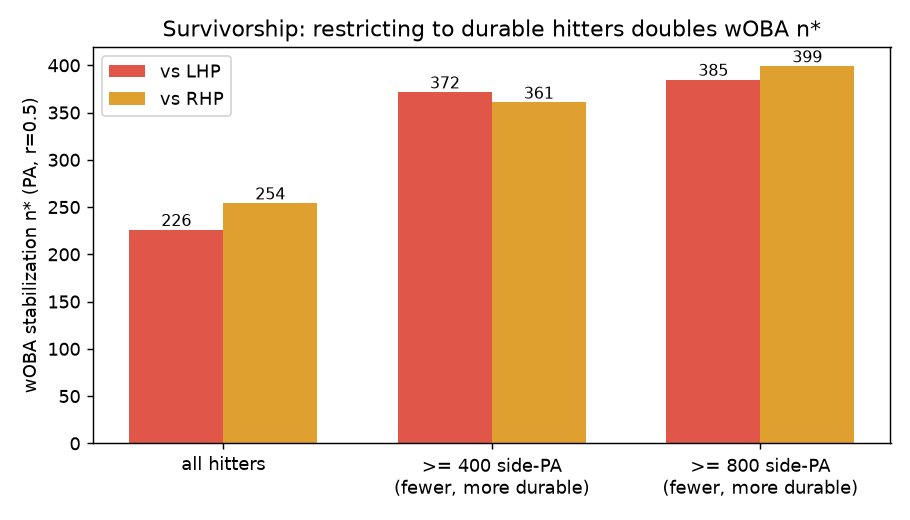

In [6]:
display(Image(filename=str(RESULTS_DIR / "fig_woba_survivorship.png")))

## Observations per plate appearance
Native units differ per metric, so the points above are not directly comparable. These are the
observed rates of pitches, swings and balls in play per plate appearance on the same table.

In [7]:
load("conversion_factors.csv").round(3)

,pitches,swings,BBIP,PA
0,3.896,1.827,0.676,1.0


## Signal per plate appearance ranking
Every stabilization point converted onto the plate appearance axis the process versus outcome
comparison has to be made on. The speedup column is measured against the faster of the two wOBA
splits, so the comparison is stated against the outcome's best case.

In [8]:
ranking = load("signal_per_pa_ranking.csv")
fastest_outcome_pa = ranking.loc[ranking["kind"] == "outcome", "vc_n50_pa_equiv"].min()
ranking["speedup_vs_fastest_outcome"] = (fastest_outcome_pa / ranking["vc_n50_pa_equiv"]).round(2)
ranking.round({"vc_n50_native": 1, "obs_per_pa": 3, "vc_n50_pa_equiv": 1})

,metric,unit,vc_n50_native,obs_per_pa,vc_n50_pa_equiv,kind,speedup_vs_fastest_outcome
0,whiff rate,swings,54.3,1.827,29.7,process,7.60
1,swing rate,pitches,122.9,3.896,31.6,process,7.16
2,exit velocity,BBIP,45.2,0.676,66.8,process,3.39
3,launch angle,BBIP,46.4,0.676,68.5,process,3.30
4,spray angle,BBIP,77.4,0.676,114.5,process,1.97
5,wOBA vs LHP,PA,226.0,1.000,226.0,outcome,1.00
6,wOBA vs RHP,PA,254.1,1.000,254.1,outcome,0.89


In [9]:
display(Image(filename=str(RESULTS_DIR / "fig_signal_per_pa_ranking.png")))

## Near plate spray artifact treatments
Spray angle comes from hit coordinates and the formula blows up when those coordinates sit near
the plate origin, producing values outside the foul line wedge that cannot be real batted ball
directions. This prices the three treatments: keep the raw angle, clip it, or null the rows.

In [10]:
spray = load("spray_clipping.csv")
spray["artifact_share"] = (spray["n_gt90"] / spray["n_bbip"]).round(5)
spray.round({"vc_n50": 1, "vc_n50_lo": 1, "vc_n50_hi": 1, "splithalf_random_50": 1})

,treatment,n_bbip,n_gt90,n_hitters,vc_n50,vc_n50_lo,vc_n50_hi,splithalf_random_50,artifact_share
0,unclipped,1004409,9575,1681,88.4,78.6,98.9,84.5,0.00953
1,clipped_90,1004409,9575,1681,81.7,72.4,91.6,77.8,0.00953
2,dropped_gt90,994834,0,1681,77.4,68.6,87.0,78.1,0.00000


In [11]:
display(Image(filename=str(RESULTS_DIR / "fig_spray_clipping.png")))

## Context feature screen verdicts
One XGBoost head per process outcome, fitted on the exact 48 dim context vector the model will
consume and scored by out of sample permutation importance on the validation season. A feature
keeps if permuting it costs at least 1 percent of some head's baseline metric or if the
architecture freezes it in, and nothing is auto dropped.

In [12]:
decisions = load("feature_screening_feature_decisions.csv")
decisions.sort_values(["verdict", "best_perm_norm"], ascending=[True, False])[
    ["group", "verdict", "frozen_in", "best_head", "best_perm_norm"]].round(5)

,group,verdict,frozen_in,best_head,best_perm_norm
0,effective_speed,flag,False,spray,0.00813
1,release_pos_z,flag,False,whiff,0.00751
2,spin_axis,flag,False,whiff,0.00541
3,release_spin_rate,flag,False,la,0.00190
4,release_pos_y,flag,False,ev,0.00064
5,release_extension,flag,False,spray,0.00064
6,plate_x,keep,False,swing,0.77188
7,plate_z,keep,False,swing,0.68261
8,count,keep,True,swing,0.30729
9,pfx_x,keep,False,swing,0.13562


## Whether the screen fits converged
Permutation importances are only trustworthy if the fits they were read off had stopped
improving. This checks each head's stopping round against the tree budget.

In [13]:
# read off feature_screening_screen.py's fit params, where it is inline in the estimator dict rather than a
# module constant, so this is the one literal here that can silently drift
N_ESTIMATORS_CAP = 600

screen_summary = pd.DataFrame(json.loads((RESULTS_DIR / "feature_screening_screen_summary.json").read_text())).T
screen_summary["skill_vs_base_rate"] = (
    1 - screen_summary["val_metric"] / screen_summary["base_rate_metric"]).round(3)
screen_summary["hit_budget_cap"] = screen_summary["best_iteration"] >= N_ESTIMATORS_CAP - 1
screen_summary

,task,n_train,n_val,val_metric,base_rate_metric,best_iteration,skill_vs_base_rate,hit_budget_cap
swing,clf,5937276,705351,0.447632,0.692176,599,0.353,True
whiff,clf,2783491,337138,0.436563,0.543165,599,0.196,True
ev,reg,1027856,122345,12.213902,13.984244,599,0.127,True
la,reg,1027988,122408,26.329308,28.559727,599,0.078,True
spray,reg,1002557,121485,26.804861,28.505922,522,0.06,False


## What these measurements settle
- Process becomes usable several fold faster per plate appearance than side specific wOBA, not an order of magnitude: whiff and swing about 7x, exit velocity and launch angle about 3x, spray about 2x. The ordering holds across both thresholds, both split types and both estimators.
- Split half is survivorship biased at large n on the outcome metric. Variance components is the headline and split half stays a cross check.
- The wOBA vs LHP point of about 226 PA anchors the exposure strata used in notebook 03.
- The spray artifact is 0.95 percent of balls in play, confirming a figure asserted earlier and never checked. Nulling is chosen on physical grounds; the reliability gain is directional only and nothing downstream depends on the choice.
- Ten context features keep and six flag, with plate location and count dominating.

## What it leaves open
- The six flags are undecided and no ablation owns the decision, so they would enter the model undecided. Their deferral target was cancelled when bat tracking left scope and was never re-homed.
- They must not be dropped on this evidence. Four of the five fits hit the tree budget rather than converging, and the flagged set is exactly the collinear one, which deflates permutation importance.
- The test that settles it, not run: re-fit until early stopping fires on every head, and permute the correlated features jointly as blocks.
- The variance components versus split half gap on wOBA is attributed here to survivorship. Heteroscedasticity fits the same table and is not ruled out.
- Becoming reliable quickly is not the same as projecting. Notebook 03 tests that.